<a href="https://colab.research.google.com/github/Bhardwajsimran/mental-health/blob/main/Iris_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

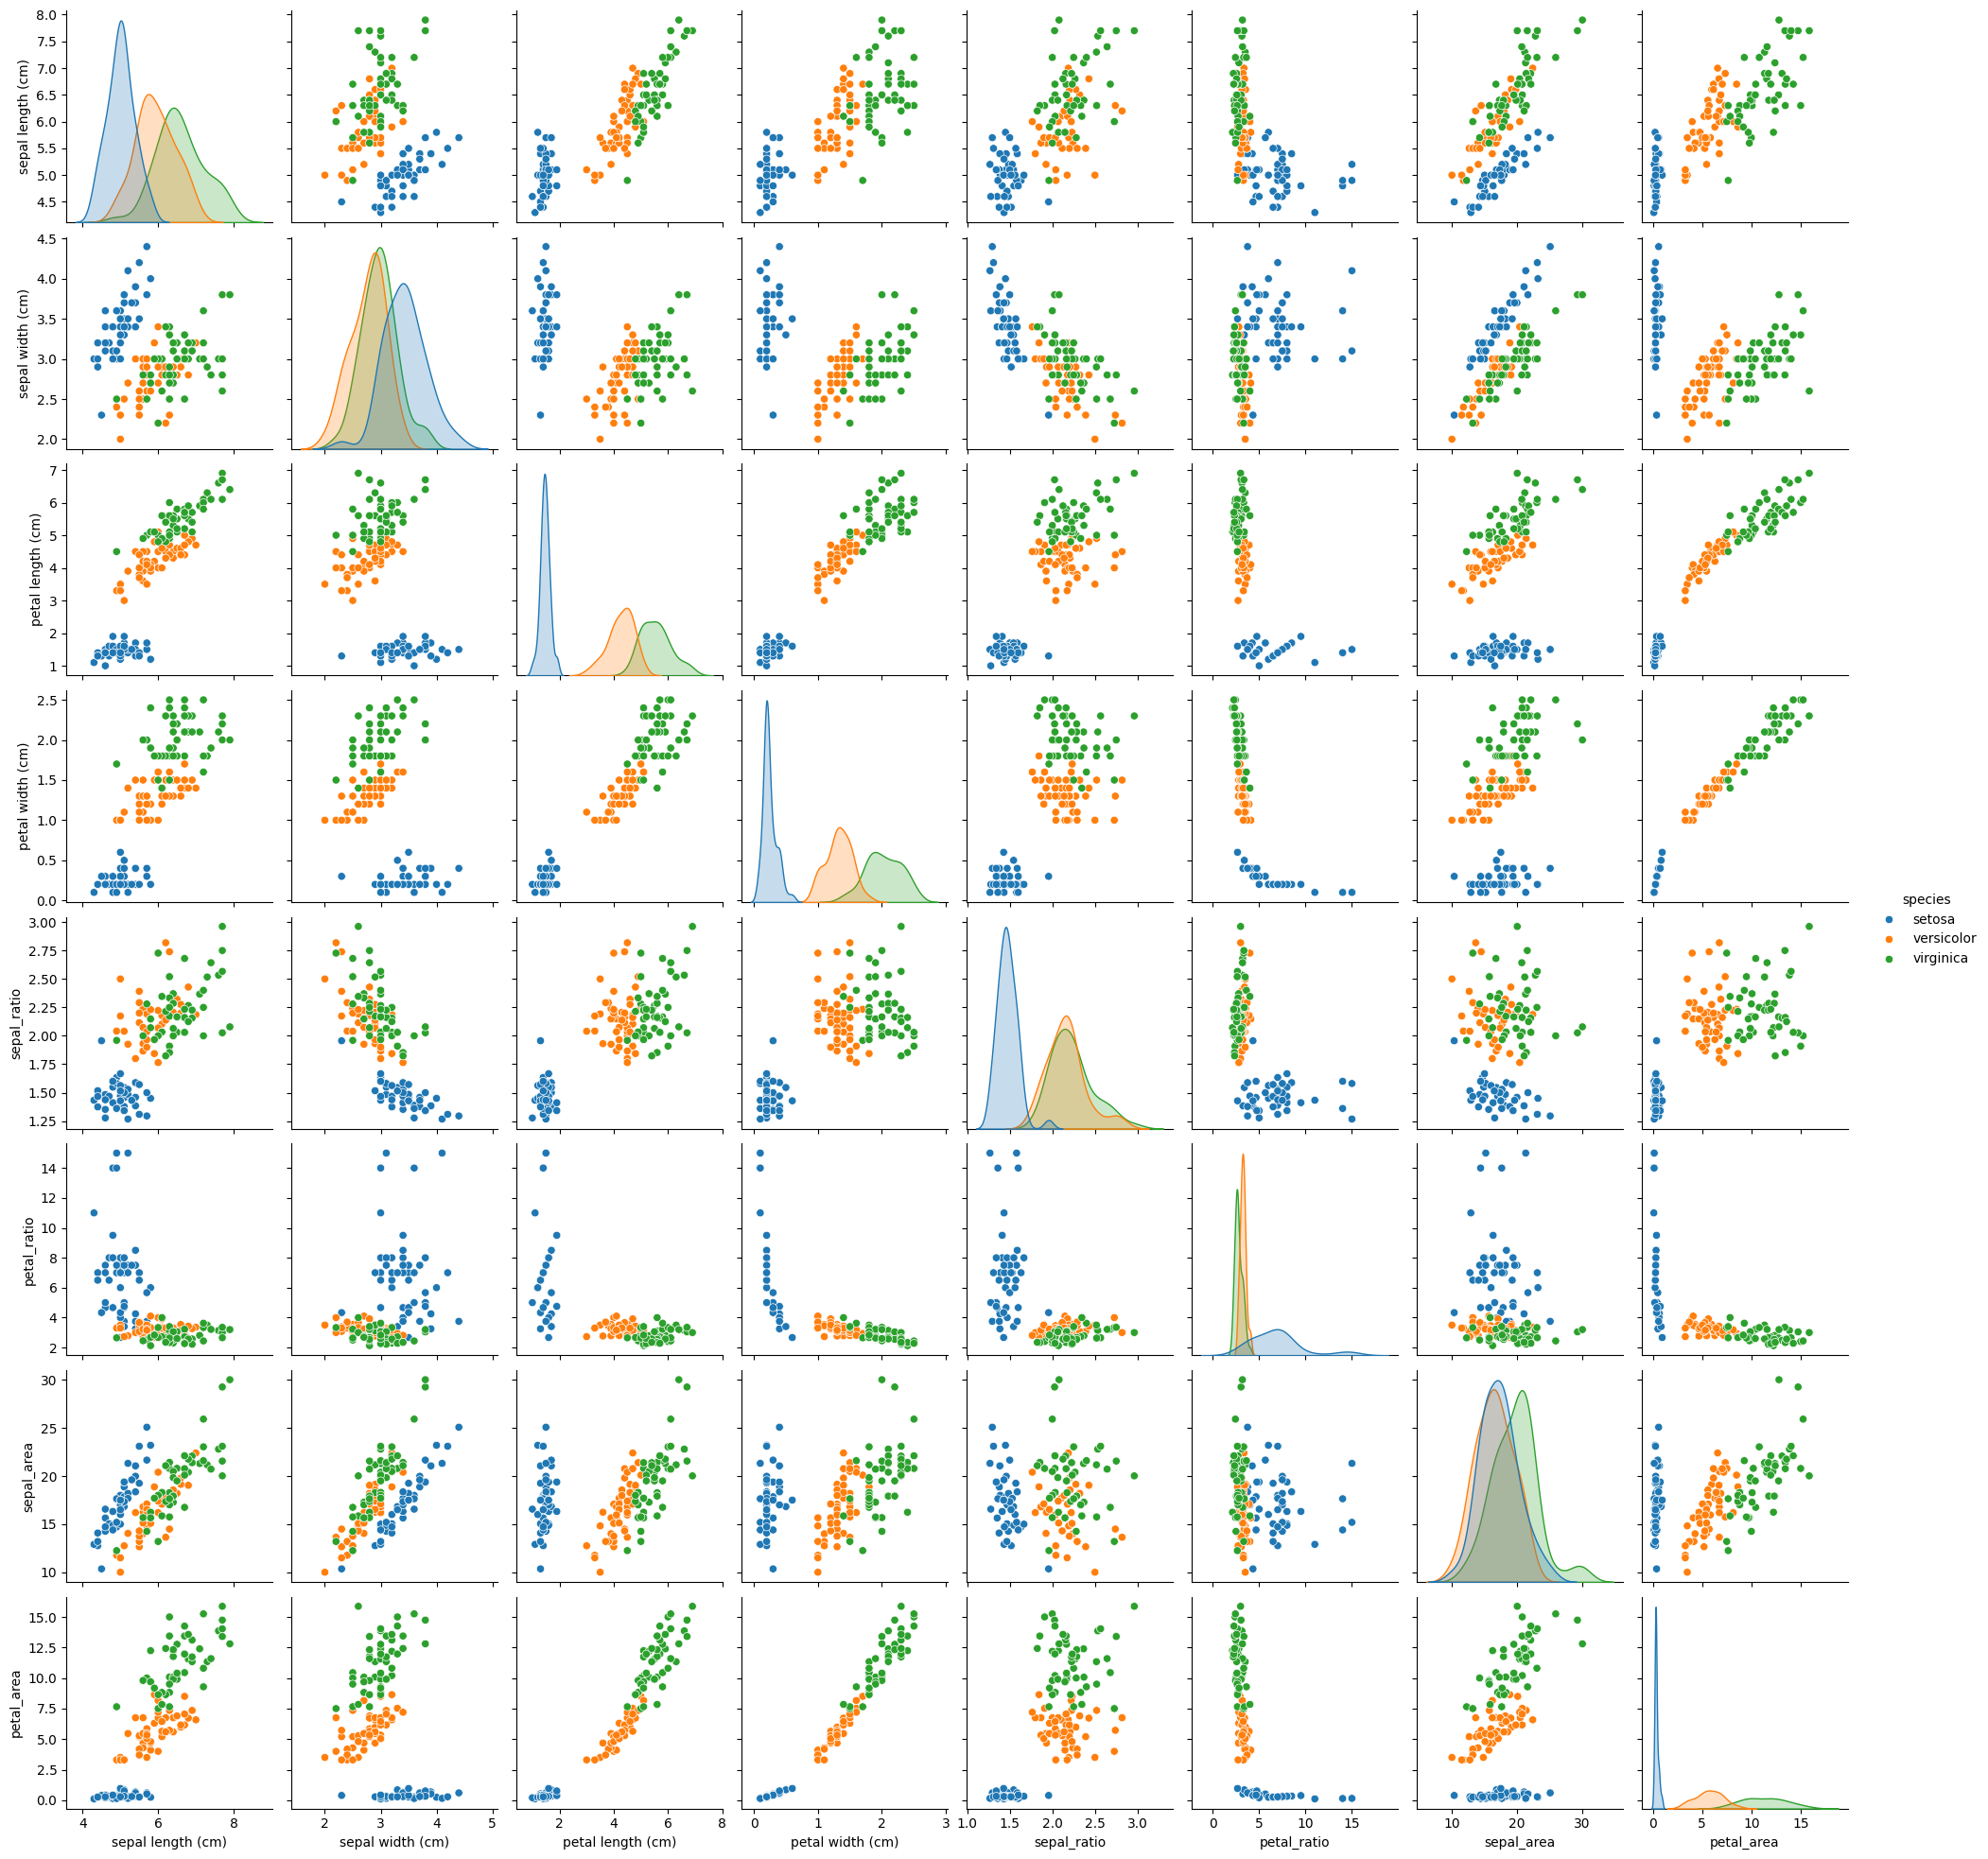

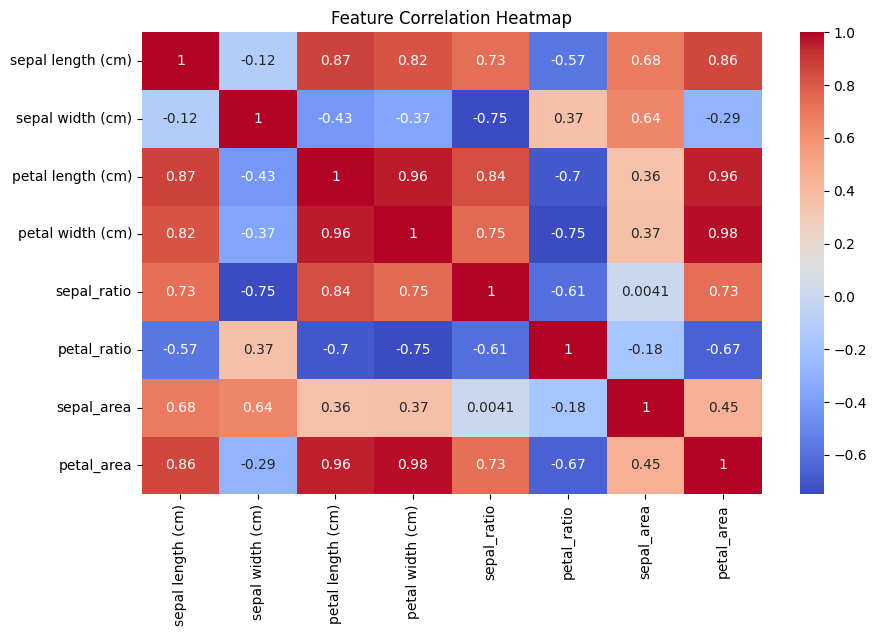


Logistic Regression
Accuracy: 0.9667
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



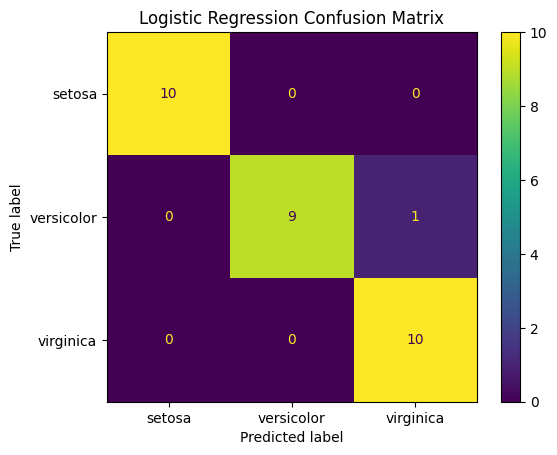


KNN
Accuracy: 0.9333
[[10  0  0]
 [ 0 10  0]
 [ 0  2  8]]
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



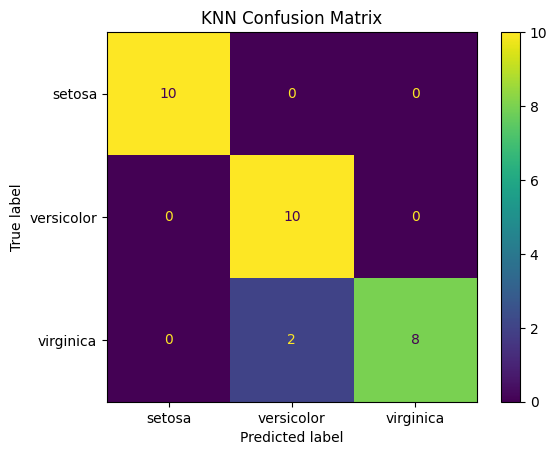


Decision Tree
Accuracy: 0.9
[[10  0  0]
 [ 0  8  2]
 [ 0  1  9]]
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.89      0.80      0.84        10
   virginica       0.82      0.90      0.86        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



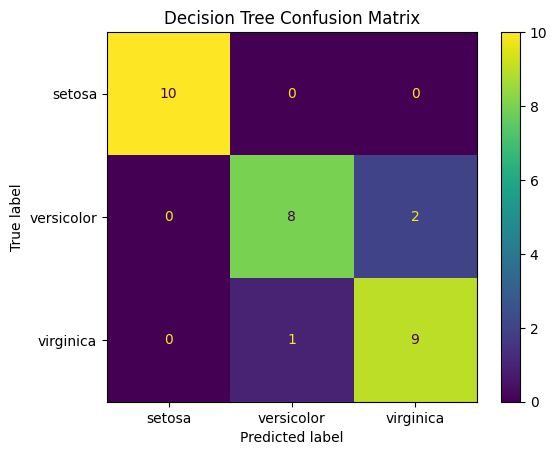


Random Forest
Accuracy: 0.9667
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



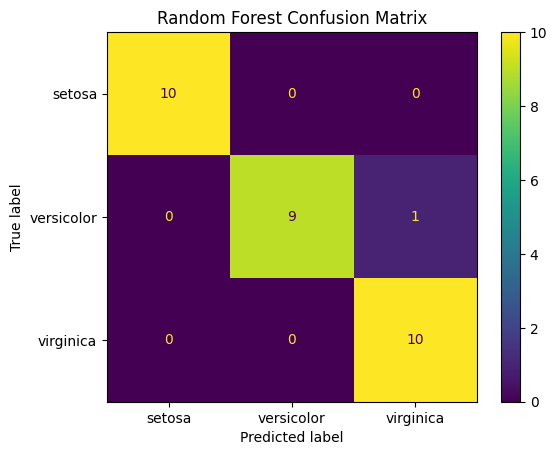


Gradient Boosting
Accuracy: 0.9
[[10  0  0]
 [ 0  8  2]
 [ 0  1  9]]
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.89      0.80      0.84        10
   virginica       0.82      0.90      0.86        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



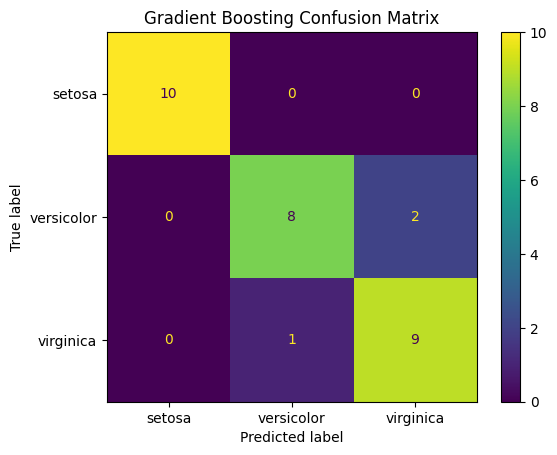

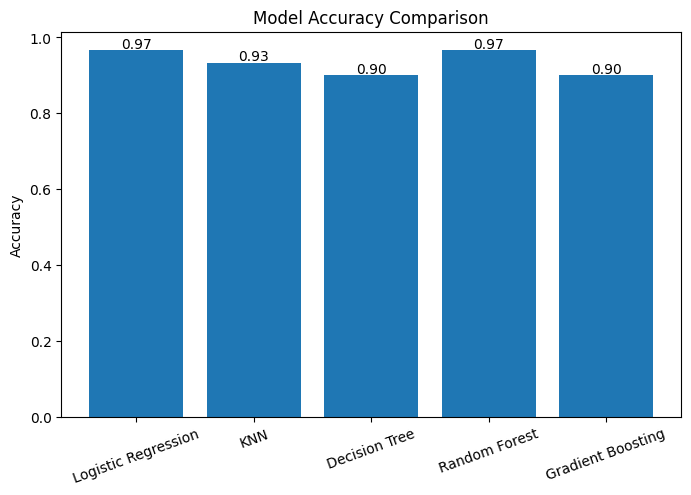


BEST MODEL: Logistic Regression
Accuracy: 0.9666666666666667

Model + Scaler Saved Successfully!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Sample Prediction: setosa


In [5]:
# ==================================================
# IMPORTS
# ==================================================
import numpy as np
import pandas as pd

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

import joblib
import matplotlib.pyplot as plt
import seaborn as sns

# ==================================================
# LOAD DATA
# ==================================================
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)

df["species"] = pd.Series(iris.target).map({
    0: "setosa",
    1: "versicolor",
    2: "virginica"
})

# ==================================================
# FEATURE ENGINEERING
# ==================================================
df["sepal_ratio"] = df["sepal length (cm)"] / (df["sepal width (cm)"] + 1e-6)
df["petal_ratio"] = df["petal length (cm)"] / (df["petal width (cm)"] + 1e-6)
df["sepal_area"] = df["sepal length (cm)"] * df["sepal width (cm)"]
df["petal_area"] = df["petal length (cm)"] * df["petal width (cm)"]

# ==================================================
# EDA VISUALS
# ==================================================
sns.pairplot(df, hue="species")
plt.show()

plt.figure(figsize=(10,6))
sns.heatmap(df.drop("species", axis=1).corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

# ==================================================
# FEATURES / TARGET
# ==================================================
X = df.drop("species", axis=1)
y = df["species"]

# ==================================================
# TRAIN TEST SPLIT
# ==================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ==================================================
# SCALING
# ==================================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==================================================
# MODELS
# ==================================================
models = {
    "Logistic Regression": LogisticRegression(max_iter=300),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

# ==================================================
# TRAIN + EVALUATE
# ==================================================
results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

    print("\n==============================")
    print(name)
    print("Accuracy:", round(acc, 4))
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))

    # Confusion Matrix Plot
    ConfusionMatrixDisplay.from_estimator(model, X_test_scaled, y_test)
    plt.title(f"{name} Confusion Matrix")
    plt.show()

# ==================================================
# MODEL COMPARISON CHART
# ==================================================
plt.figure(figsize=(8,5))
plt.bar(results.keys(), results.values())
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=20)

for i, v in enumerate(results.values()):
    plt.text(i, v+0.005, f"{v:.2f}", ha='center')

plt.show()

# ==================================================
# BEST MODEL
# ==================================================
best_model_name = max(results, key=results.get)
best_model = models[best_model_name]

print("\n==============================")
print("BEST MODEL:", best_model_name)
print("Accuracy:", results[best_model_name])

# ==================================================
# SAVE MODEL + SCALER
# ==================================================
joblib.dump(best_model, "iris_model.pkl")
joblib.dump(scaler, "iris_scaler.pkl")

print("\nModel + Scaler Saved Successfully!")

# ==================================================
# COLAB DOWNLOAD (SAFE)
# ==================================================
try:
    from google.colab import files
    files.download("iris_model.pkl")
    files.download("iris_scaler.pkl")
except:
    print("Not running in Colab, skipping download")

# ==================================================
# SAMPLE PREDICTION
# ==================================================
def predict(sl, sw, pl, pw):
    input_df = pd.DataFrame([[
        sl,
        sw,
        pl,
        pw,
        sl / (sw + 1e-6),
        pl / (pw + 1e-6),
        sl * sw,
        pl * pw
    ]], columns=X.columns)

    return best_model.predict(scaler.transform(input_df))[0]

print("\nSample Prediction:", predict(5.1, 3.5, 1.4, 0.2))